# Лабораторная работа №1
## Анализ и прогнозирование временных рядов на примере розничных продаж

**Данные:** `retail_sales_mock_data.csv` - месячные продажи за 2020-2023 (48 наблюдений)
+ экзогенные признаки `Promotion` и `HolidayMonth`.
**Структура:** 2.1 EDA и декомпозиция (классическая, STL, FFT, вейвлеты); 2.2 ARIMA и SARIMAX;
2.3 качество (MSE, R2, AIC, BIC, остатки); 2.4 выводы.

In [3]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pywt

mpl.rcParams["figure.figsize"] = (12, 4)
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

np.random.seed(42)
print("numpy", np.__version__, "| pandas", pd.__version__,
      "| statsmodels", sm.__version__, "| PyWavelets", pywt.__version__)


numpy 2.1.3 | pandas 2.2.3 | statsmodels 0.15.0 | PyWavelets 1.8.0


---
## 2.1. Разведочный анализ данных (EDA)

### 2.1.1. Загрузка и первичный осмотр


In [4]:
df = pd.read_csv("retail_sales_mock_data.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date").asfreq("MS")
ts = df["SalesAmount"]

print("Размер таблицы:", df.shape)
print("Период:", df.index.min().date(), "->", df.index.max().date())
df.head()


Размер таблицы: (48, 3)
Период: 2020-01-01 -> 2023-12-01


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [5]:
# Описательная статистика и целостность ряда.
# CV считаем только для SalesAmount: для бинарных признаков он неинтерпретируем.
stats = df[["SalesAmount", "Promotion", "HolidayMonth"]].describe().T
stats["cv, %"] = np.nan
stats.loc["SalesAmount", "cv, %"] = (stats.loc["SalesAmount", "std"]
                                     / stats.loc["SalesAmount", "mean"] * 100)
display(stats)
display(df.isna().sum().to_frame("пропуски"))

expected = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Ряд регулярный (ежемесячный, без пропусков):", df.index.equals(expected))
print("Число промо-месяцев:", int(df["Promotion"].sum()),
      "| праздничных месяцев:", int(df["HolidayMonth"].sum()))

,count,mean,std,min,25%,50%,75%,max,"cv, %"
SalesAmount,48.000,"11,768.542","2,257.545","7,783.000","10,219.750","11,851.000","13,014.000","17,996.000",19.183
Promotion,48.000,0.125,0.334,0.000,0.000,0.000,0.000,1.000,NaN
HolidayMonth,48.000,0.083,0.279,0.000,0.000,0.000,0.000,1.000,NaN


,пропуски
SalesAmount,0
Promotion,0
HolidayMonth,0


Ряд регулярный (ежемесячный, без пропусков): True
Число промо-месяцев: 6 | праздничных месяцев: 4


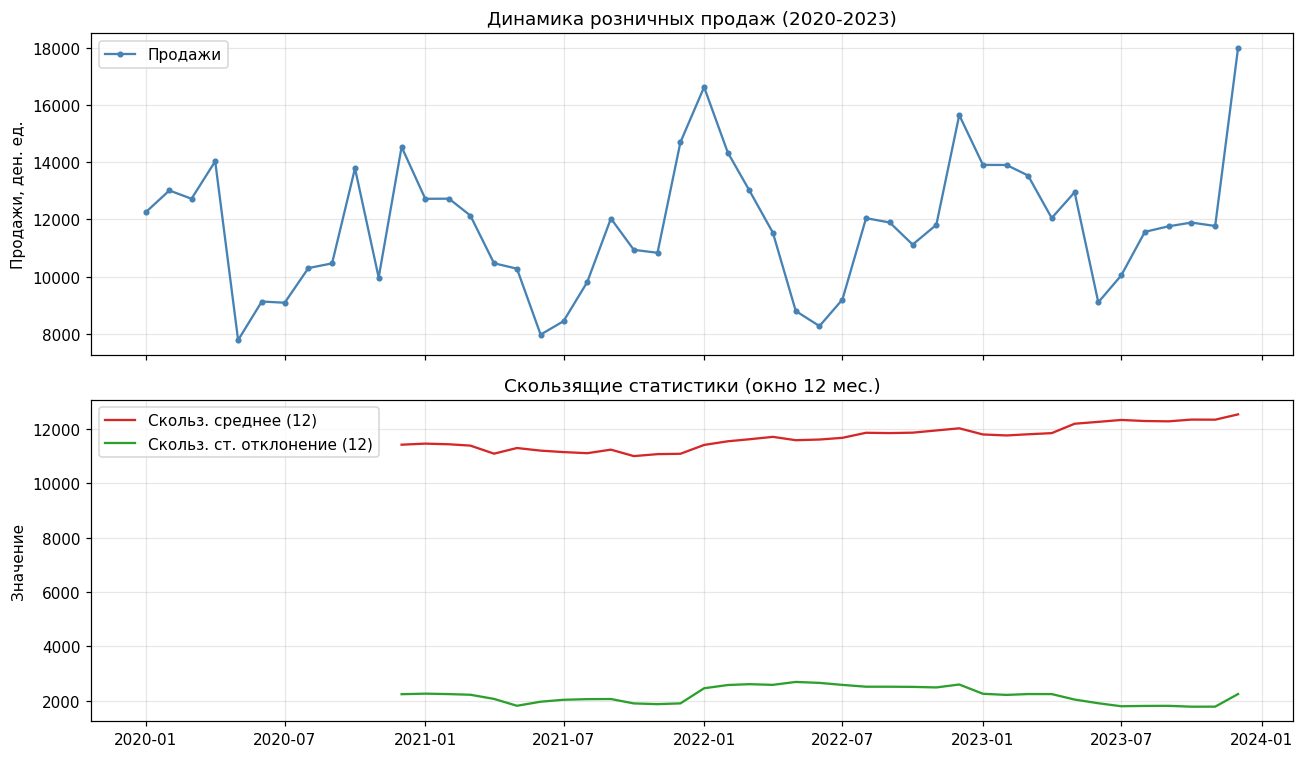

In [6]:
# Динамика ряда и скользящие статистики
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(ts.index, ts.values, marker="o", ms=3, color="steelblue", label="Продажи")
axes[0].set_title("Динамика розничных продаж (2020-2023)")
axes[0].set_ylabel("Продажи, ден. ед.")
axes[0].legend()
axes[1].plot(ts.index, ts.rolling(12).mean(), color="tab:red", label="Скольз. среднее (12)")
axes[1].plot(ts.index, ts.rolling(12).std(), color="tab:green", label="Скольз. ст. отклонение (12)")
axes[1].set_title("Скользящие статистики (окно 12 мес.)")
axes[1].set_ylabel("Значение")
axes[1].legend()
plt.tight_layout()
plt.show()


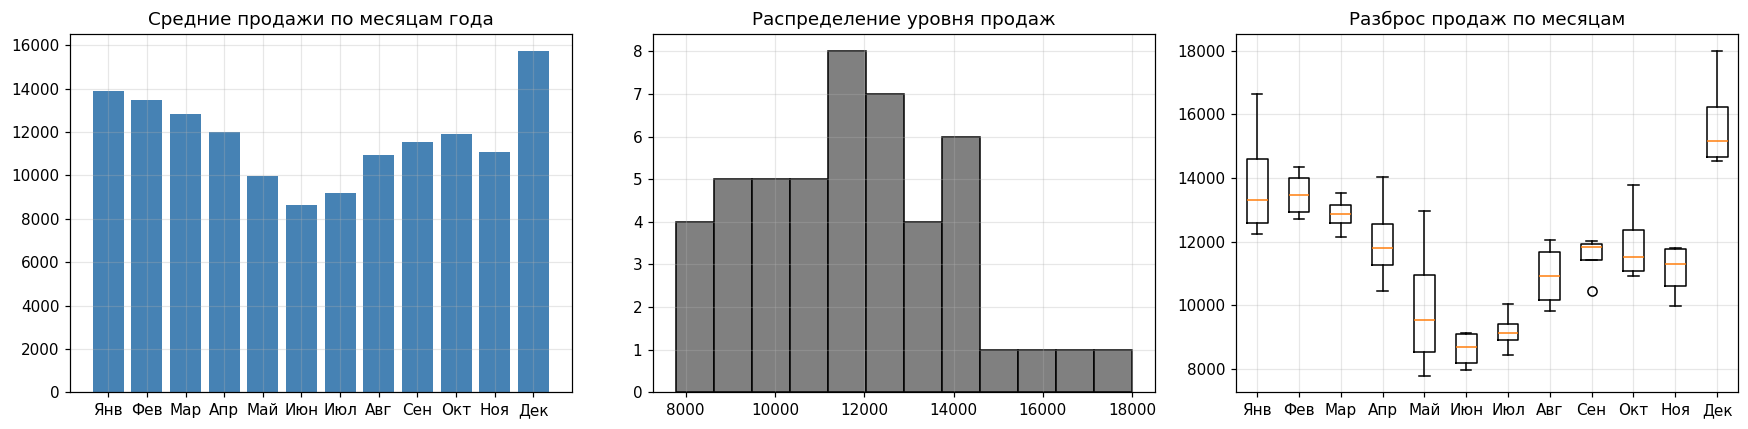

Средний уровень по месяцам (отсортировано):
Месяц
12    15718
1     13874
2     13493
3     12854
4     12021
10    11934
9     11536
11    11096
8     10930
5      9953
7      9194
6      8621


In [7]:
# Сезонный профиль, распределение и разброс по месяцам
month_names = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
               "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"]
profile = ts.groupby(ts.index.month).mean().reindex(range(1, 13))
profile.index.name = "Месяц"

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(month_names, profile.values, color="steelblue")
axes[0].set_title("Средние продажи по месяцам года")
axes[1].hist(ts, bins=12, color="gray", edgecolor="k")
axes[1].set_title("Распределение уровня продаж")
axes[2].boxplot([ts[ts.index.month == m].values for m in range(1, 13)],
                tick_labels=month_names)
axes[2].set_title("Разброс продаж по месяцам")
plt.tight_layout()
plt.show()

print("Средний уровень по месяцам (отсортировано):")
print(profile.sort_values(ascending=False).round(0).astype(int).to_string())

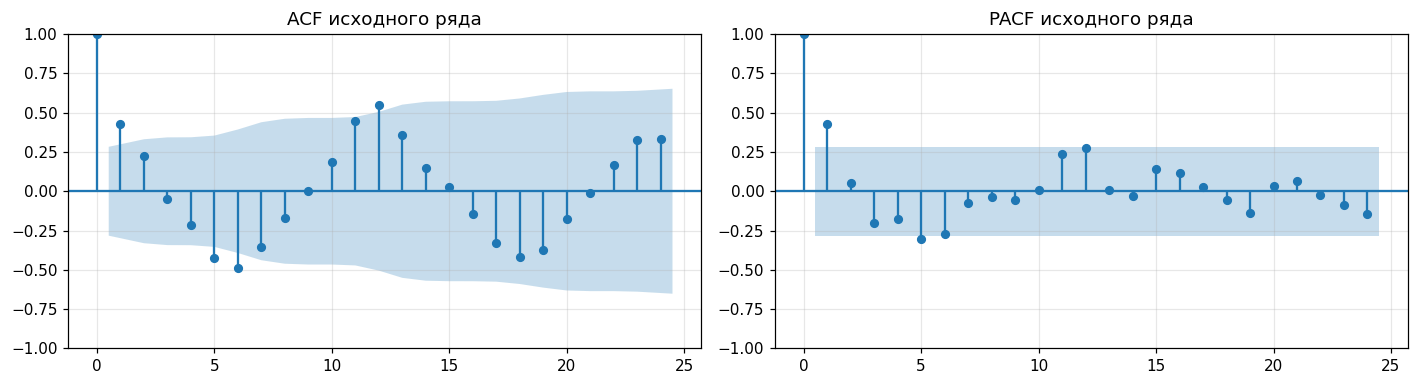

    Исходный ряд: ADF p = 0.0002 | KPSS p = 0.1000  -> СТАЦИОНАРЕН
    1-я разность: ADF p = 0.0000 | KPSS p = 0.1000  -> СТАЦИОНАРЕН
Сезонная разность: ADF p = 0.0053 | KPSS p = 0.1000  -> СТАЦИОНАРЕН


In [8]:
# ACF/PACF и тесты на стационарность.
# ADF: H0 - единичный корень; KPSS: H0 - стационарность (p-value KPSS ограничен сверху 0.10).
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
plot_acf(ts, lags=24, ax=axes[0]); axes[0].set_title("ACF исходного ряда")
plot_pacf(ts, lags=24, method="ywm", ax=axes[1]); axes[1].set_title("PACF исходного ряда")
plt.tight_layout()
plt.show()

def stationarity_report(x, name):
    x = np.asarray(x)
    adf_p = adfuller(x, autolag="AIC")[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            kpss_p = kpss(x, regression="c", nlags="auto")[1]
        except Exception:
            kpss_p = np.nan
    verdict = "СТАЦИОНАРЕН" if (adf_p < 0.05 and (np.isnan(kpss_p) or kpss_p > 0.05)) else "НЕ стационарен"
    print(f"{name:>16}: ADF p = {adf_p:.4f} | KPSS p = {kpss_p:.4f}  -> {verdict}")

stationarity_report(ts, "Исходный ряд")
stationarity_report(ts.diff().dropna(), "1-я разность")
stationarity_report(ts.diff(12).dropna(), "Сезонная разность")

**Выводы по 2.1.1.**
* Ряд регулярный: 48 месячных наблюдений, пропусков нет.
* Слабый тренд + сильная годовая сезонность (пик в декабре, провал в мае-июне); разброс растёт с уровнем.
* ADF/KPSS стационарность не отвергают (p ~ 0.0002 / p >= 0.10), но ACF затухает медленно,
  поэтому в моделях страховочно используем разности d = 1 и D = 1 (подтверждено AIC в п. 2.2).

### 2.1.2. Декомпозиция ряда: четыре подхода

#### (a) Классическая аддитивная и мультипликативная декомпозиция


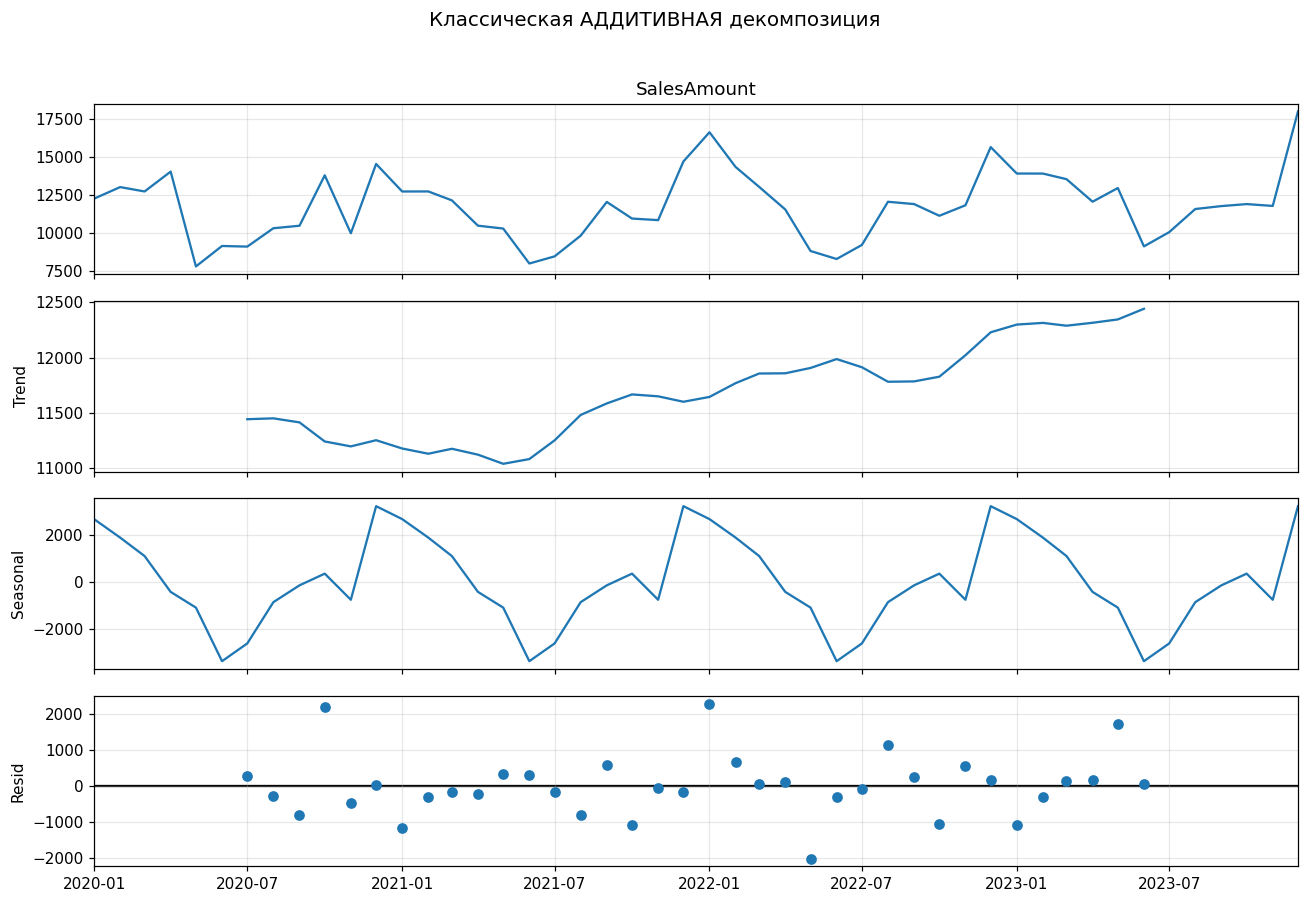

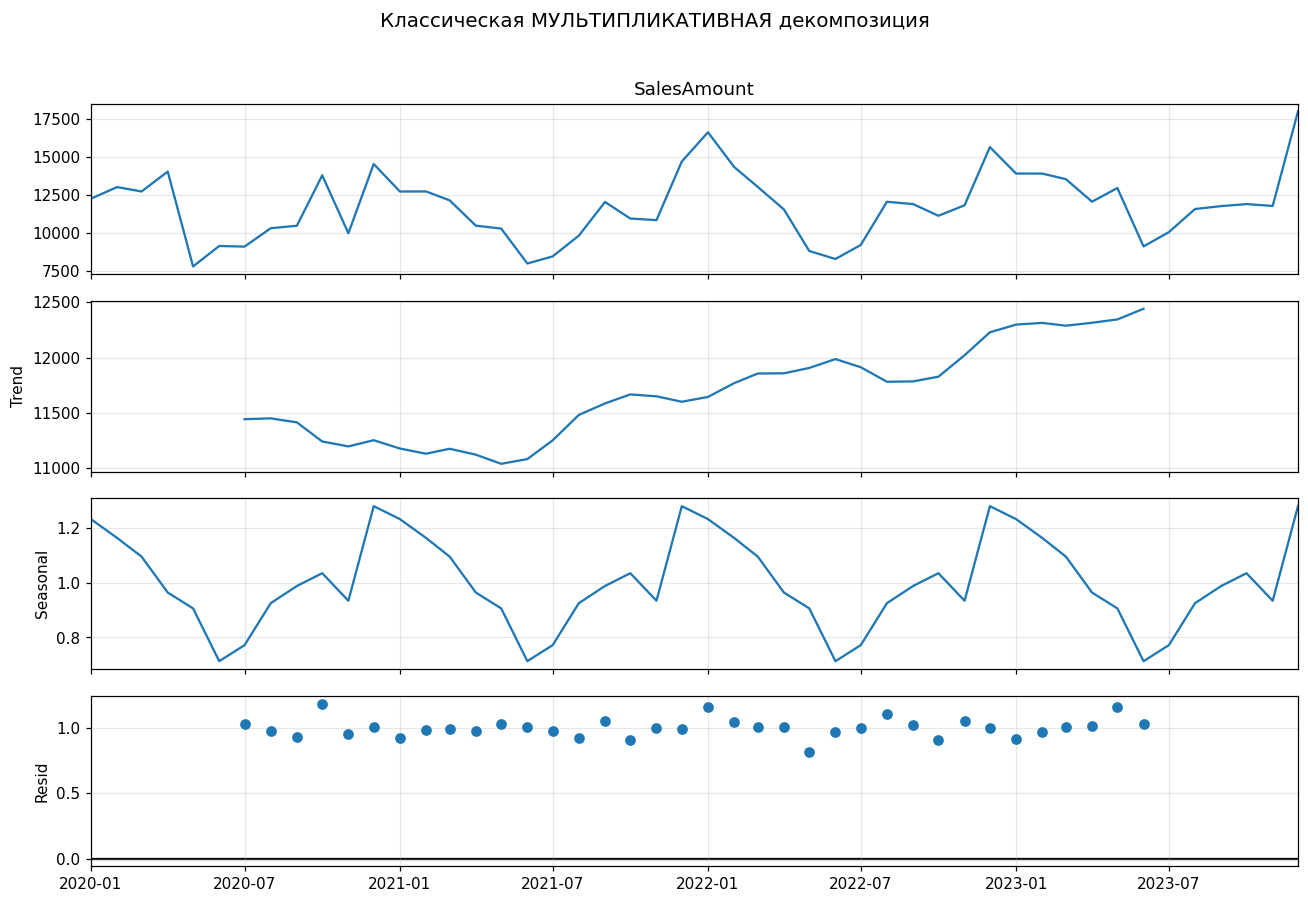

In [9]:
dec_add = seasonal_decompose(ts, model="additive", period=12)
dec_mul = seasonal_decompose(ts, model="multiplicative", period=12)

for dec, title in [(dec_add, "Классическая АДДИТИВНАЯ декомпозиция"),
                   (dec_mul, "Классическая МУЛЬТИПЛИКАТИВНАЯ декомпозиция")]:
    fig = dec.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


#### (b) STL-декомпозиция (robust)


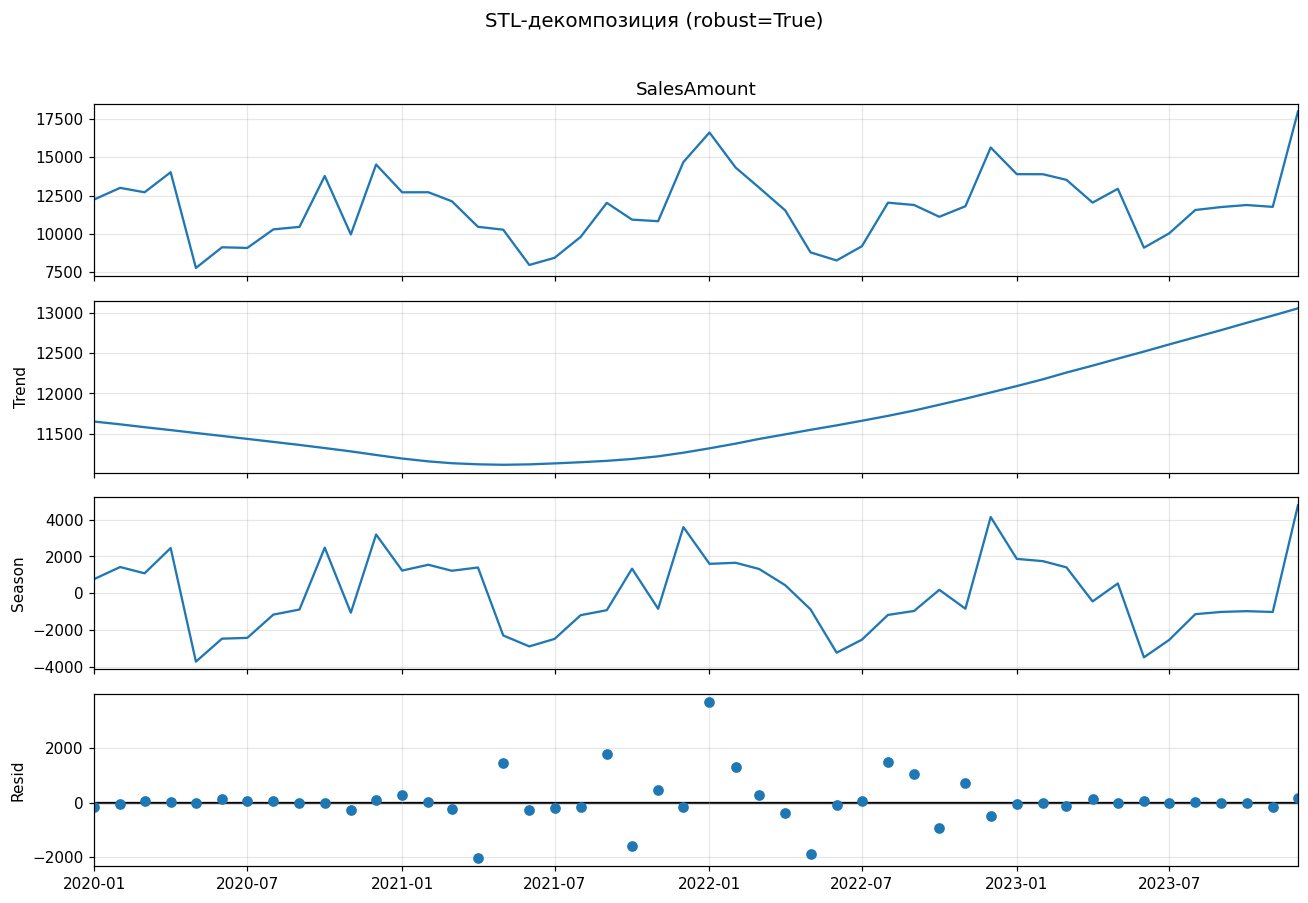

In [10]:
stl = STL(ts, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL-декомпозиция (robust=True)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
# Сила компонент: F = max(0, 1 - Var(R)/Var(C+R)) (мера Wang-Smith-Hyndman).
# Мультипликативную модель считаем в лог-шкале: у statsmodels trend в исходных единицах,
# а resid в долях - прямая подстановка даёт артефакт F_T = 1.
def component_strength(resid, comp):
    resid = np.asarray(resid, float); comp = np.asarray(comp, float)
    denom = np.nanvar(resid + comp)
    return max(0.0, 1 - np.nanvar(resid) / denom) if denom > 0 else 0.0

rows = []
rows.append({"Метод": "Классическая аддитивная",
             "Сила тренда": component_strength(dec_add.resid, dec_add.trend),
             "Сила сезонности": component_strength(dec_add.resid, dec_add.seasonal),
             "Ст. откл. остатка": np.nanstd(dec_add.resid),
             "Единицы остатка": "ден. ед."})
mt, ms, mr = np.log(dec_mul.trend), np.log(dec_mul.seasonal), np.log(dec_mul.resid)
rows.append({"Метод": "Классическая мультипликативная (в логах)",
             "Сила тренда": component_strength(mr, mt),
             "Сила сезонности": component_strength(mr, ms),
             "Ст. откл. остатка": np.nanstd(mr) * 100,
             "Единицы остатка": "% (лог-шкала)"})
rows.append({"Метод": "STL (robust)",
             "Сила тренда": component_strength(stl.resid, stl.trend),
             "Сила сезонности": component_strength(stl.resid, stl.seasonal),
             "Ст. откл. остатка": np.nanstd(stl.resid),
             "Единицы остатка": "ден. ед."})
strength_df = pd.DataFrame(rows).set_index("Метод")
display(strength_df)
print("Остаток: %.1f%% уровня (аддитивная) и %.1f%% (мультипликативная) ->"
      % (np.nanstd(dec_add.resid) / ts.mean() * 100, np.nanstd(mr) * 100))
print("амплитуда колебаний почти пропорциональна уровню, сезонность близка к мультипликативной.")

,Сила тренда,Сила сезонности,Ст. откл. остатка,Единицы остатка
Метод,,,,
Классическая аддитивная,0.210,0.833,859.236,ден. ед.
Классическая мультипликативная (в логах),0.226,0.845,7.169,% (лог-шкала)
STL (robust),0.257,0.839,873.428,ден. ед.


Остаток: 7.3% уровня (аддитивная) и 7.2% (мультипликативная) ->
амплитуда колебаний почти пропорциональна уровню, сезонность близка к мультипликативной.


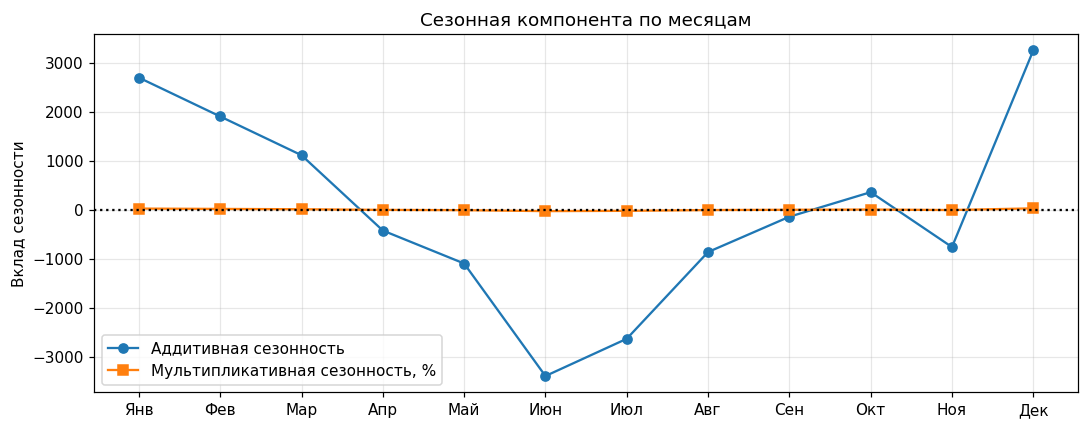

In [12]:
# Сравнение сезонных профилей (аддитивная vs мультипликативная сезонность)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_names, dec_add.seasonal.iloc[:12].values, marker="o", label="Аддитивная сезонность")
ax.plot(month_names, (dec_mul.seasonal.iloc[:12].values - 1) * 100, marker="s",
        label="Мультипликативная сезонность, %")
ax.axhline(0, color="k", ls=":")
ax.set_title("Сезонная компонента по месяцам")
ax.set_ylabel("Вклад сезонности")
ax.legend()
plt.tight_layout()
plt.show()


#### (c) Спектральный анализ на основе быстрого преобразования Фурье (FFT)


Топ-6 спектральных пиков (по амплитуде):
  период =  12.00 мес.  (частота = 0.0833 цикл/мес.),  амплитуда =   2403.3
  период =   4.00 мес.  (частота = 0.2500 цикл/мес.),  амплитуда =    854.3
  период =  48.00 мес.  (частота = 0.0208 цикл/мес.),  амплитуда =    616.4
  период =   2.40 мес.  (частота = 0.4167 цикл/мес.),  амплитуда =    564.2
  период =   2.09 мес.  (частота = 0.4792 цикл/мес.),  амплитуда =    545.1
  период =   2.18 мес.  (частота = 0.4583 цикл/мес.),  амплитуда =    517.0


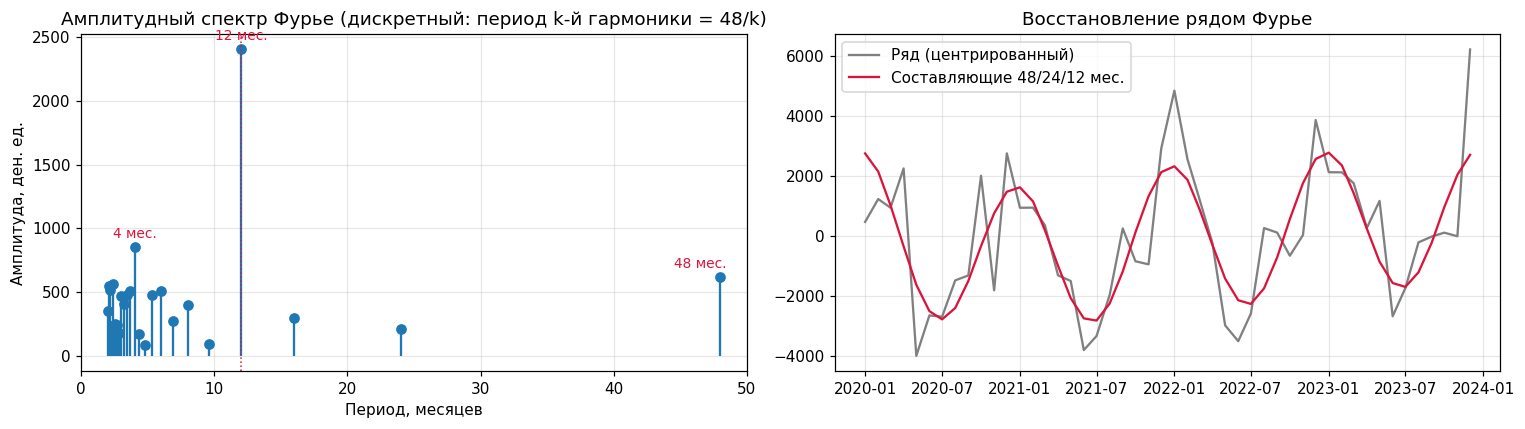

In [13]:
x = ts.values - ts.values.mean()      # убираем постоянную составляющую
n = len(x)
freqs = np.fft.rfftfreq(n, d=1.0)      # частота, цикл/месяц
amps = np.abs(np.fft.rfft(x)) / n
amps[1:n // 2] *= 2                    # удвоение только для 0 < k < n/2 (Найквист k=n/2 - нет)

mask = freqs > 0
periods = 1.0 / freqs[mask]
amps_pos = amps[mask]

order = np.argsort(amps_pos)[::-1][:6]
print("Топ-6 спектральных пиков (по амплитуде):")
for i in order:
    print(f"  период = {periods[i]:6.2f} мес.  (частота = {freqs[mask][i]:.4f} цикл/мес.),  "
          f"амплитуда = {amps_pos[i]:8.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].stem(periods, amps_pos, basefmt=" ")
axes[0].set_xlim(0, 50)                # до 50 мес., чтобы пик 48 мес. не обрезался
axes[0].set_xlabel("Период, месяцев"); axes[0].set_ylabel("Амплитуда, ден. ед.")
axes[0].set_title("Амплитудный спектр Фурье (дискретный: период k-й гармоники = 48/k)")
axes[0].axvline(12, color="crimson", ls=":", lw=1)
for i in order[:3]:                    # подписи трёх главных пиков
    ha = "right" if periods[i] > 40 else "center"
    axes[0].annotate(f"{periods[i]:.0f} мес.", (periods[i], amps_pos[i]),
                     textcoords="offset points", xytext=(4 if ha == "right" else 0, 6),
                     ha=ha, fontsize=9, color="crimson")
# Реконструкция низкочастотными составляющими: k = 1, 2, 4 -> периоды 48/24/12 мес.
# (это не гармоники годового цикла - те были бы k = 4, 8, 12).
recon = np.zeros(n)
X = np.fft.rfft(x)
for k in [1, 2, 4]:
    recon += 2 * np.abs(X[k]) / n * np.cos(2 * np.pi * k * np.arange(n) / n + np.angle(X[k]))
axes[1].plot(ts.index, x, label="Ряд (центрированный)", color="gray")
axes[1].plot(ts.index, recon, label="Составляющие 48/24/12 мес.", color="crimson")
axes[1].set_title("Восстановление рядом Фурье")
axes[1].legend()
plt.tight_layout()
plt.show()

#### (d) Вейвлет-анализ (Морле и Добеши)


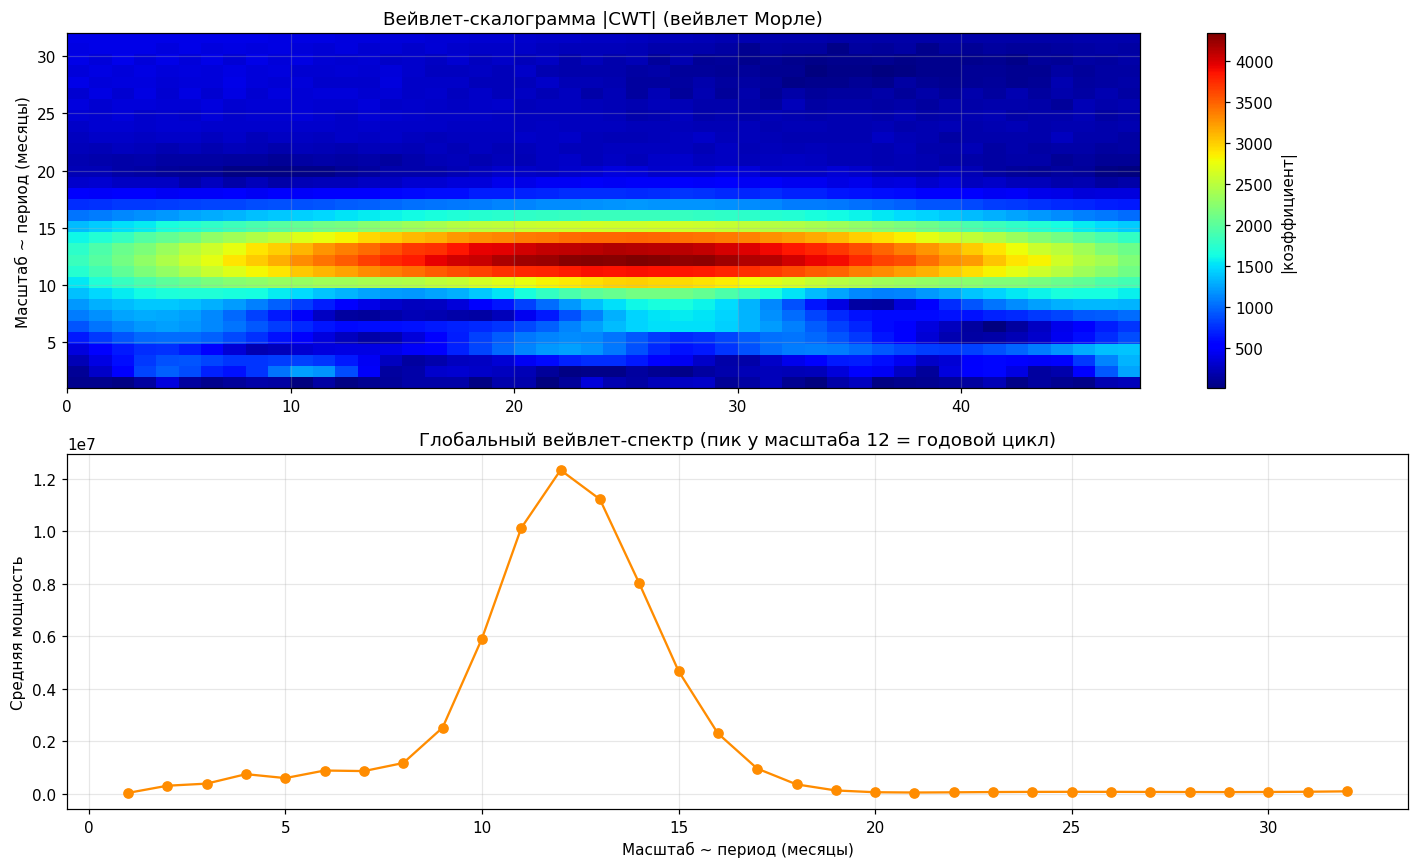

In [14]:
# CWT с комплексным вейвлетом Морле (cmor1.5-1.0): центральная частота 1 цикл/отсчёт,
# поэтому масштаб ~ период в месяцах. При масштабах >= 24 доминируют граничные эффекты (n = 48).
scales = np.arange(1, 33)
coeffs, w_freqs = pywt.cwt(x, scales, "cmor1.5-1.0", sampling_period=1.0)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
im = axes[0].imshow(np.abs(coeffs), extent=[0, n, scales[0], scales[-1]],
                    aspect="auto", cmap="jet", origin="lower")
axes[0].set_ylabel("Масштаб ~ период (месяцы)")
axes[0].set_title("Вейвлет-скалограмма |CWT| (вейвлет Морле)")
fig.colorbar(im, ax=axes[0], label="|коэффициент|")

power = (np.abs(coeffs) ** 2).mean(axis=1)   # глобальный вейвлет-спектр
axes[1].plot(scales, power, marker="o", color="darkorange")
axes[1].set_xlabel("Масштаб ~ период (месяцы)"); axes[1].set_ylabel("Средняя мощность")
axes[1].set_title("Глобальный вейвлет-спектр (пик у масштаба 12 = годовой цикл)")
plt.tight_layout()
plt.show()

Число коэффициентов по уровням: {'cA3': 12, 'cD3': 12, 'cD2': 17, 'cD1': 27}


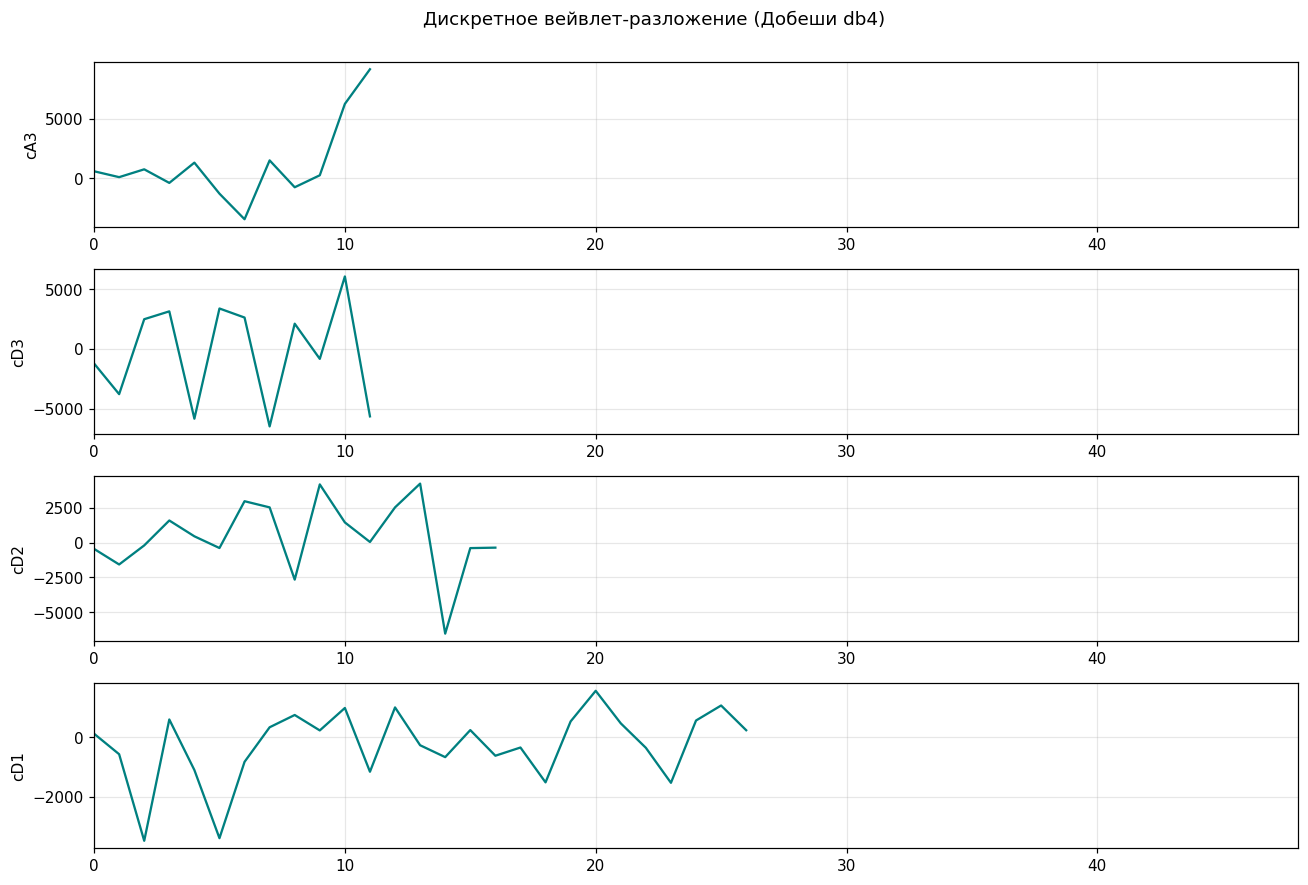

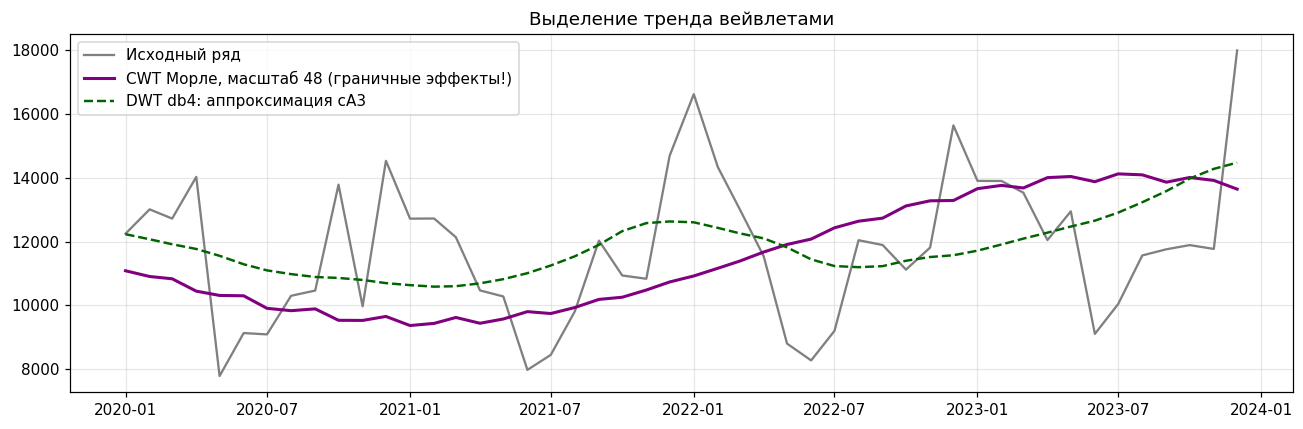

In [15]:
# DWT (Добеши db4), 3 уровня
wavelet = pywt.Wavelet("db4")
coeffs_dwt = pywt.wavedec(x, wavelet, level=3)
names = [f"cA{len(coeffs_dwt) - 1}"] + [f"cD{len(coeffs_dwt) - 1 - i}"
                                         for i in range(len(coeffs_dwt) - 1)]
print("Число коэффициентов по уровням:", dict(zip(names, [c.shape[0] for c in coeffs_dwt])))

fig, axes = plt.subplots(len(coeffs_dwt), 1, figsize=(12, 8))
for ax, c, nm in zip(axes, coeffs_dwt, names):
    ax.plot(c, color="teal"); ax.set_ylabel(nm); ax.set_xlim(0, n)
fig.suptitle("Дискретное вейвлет-разложение (Добеши db4)", y=1.0)
plt.tight_layout()
plt.show()

# "Тренд" двумя способами: CWT на масштабе 48 (иллюстрация, сильны граничные эффекты)
# и DWT-реконструкция из одной аппроксимации cA3 (корректная низкочастотная составляющая).
morl_coef, _ = pywt.cwt(x, [12, 24, 48], "morl", sampling_period=1.0)
trend_cwt = np.real(morl_coef[2]) + ts.values.mean()
trend_dwt = pywt.waverec([coeffs_dwt[0]] + [None] * (len(coeffs_dwt) - 1),
                         wavelet)[:n] + ts.values.mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index, ts.values, label="Исходный ряд", color="gray")
ax.plot(ts.index, trend_cwt, label="CWT Морле, масштаб 48 (граничные эффекты!)",
        color="purple", lw=2)
ax.plot(ts.index, trend_dwt, label="DWT db4: аппроксимация cA3",
        color="darkgreen", lw=1.6, ls="--")
ax.set_title("Выделение тренда вейвлетами")
ax.legend()
plt.tight_layout()
plt.show()

**Выводы по 2.1.2 - сравнение методов декомпозиции.**

| Метод | Что выделяет | Плюсы | Минусы |
|-------|--------------|-------|--------|
| Классическая аддитивная | T, S, R (сумма) | простота, интерпретируемость | сезонность фиксирована, края ряда теряются, чувствительна к выбросам |
| Классическая мультипликативная | те же в % к уровню | корректна, если амплитуда сезонности растёт с уровнем | то же + требует положительности ряда |
| STL | T, S, R через loess | меняющаяся сезонность, robust к выбросам | не даёт единой модели, ряд всё равно нужно стабилизировать разностями |
| FFT | глобальные гармоники | точные частоты и амплитуды, O(n log n) | предполагает стационарность, нет локализации во времени, утечка спектра |
| Вейвлеты (Морле/db4) | локальные частотно-временные структуры | локализация по времени и частоте, стойкость к нестационарности | субъективен выбор вейвлета и масштабов, граничные эффекты |

**Применимость:** на коротком ряду с устойчивой сезонностью классика и STL согласованы
(сила сезонности 0.83-0.85), FFT подтверждает период 12 мес., вейвлеты показывают, что цикл
устойчив во времени. Для моделей достаточно сезонного лага 12 и слабого тренда.

---
## 2.2. Прогнозные модели ARIMA и SARIMAX

Ряд обладает годовой сезонностью (период 12) и медленно затухающей ACF, поэтому используем
разности d = 1 и D = 1 (выбор подтверждён сеткой по AIC); в SARIMAX добавляем экзогенные
признаки `Promotion` и `HolidayMonth`. Параметры подбираем сеточным перебором по AIC на train.

In [16]:
# Разбиение на train/test с сохранением временного порядка
train = ts.loc[:"2022-12-01"]
test = ts.loc["2023-01-01":]

exog = df[["Promotion", "HolidayMonth"]].astype(float)
exog_train = exog.loc[train.index]
exog_test = exog.loc[test.index]

print("Обучающая выборка:", train.index.min().date(), "->", train.index.max().date(),
      f"| {len(train)} наблюдений")
print("Тестовая выборка: ", test.index.min().date(), "->", test.index.max().date(),
      f"| {len(test)} наблюдений (горизонт = {len(test)} мес.)")


Обучающая выборка: 2020-01-01 -> 2022-12-01 | 36 наблюдений
Тестовая выборка:  2023-01-01 -> 2023-12-01 | 12 наблюдений (горизонт = 12 мес.)


In [17]:
def fit_sarimax(endog, order, seasonal_order=(0, 0, 0, 0), exog=None):
    # enforce_* отключены: короткий ряд и нестабильная оптимизация на границах
    model = SARIMAX(endog, exog=exog, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    return model.fit(disp=False, maxiter=300)

# --- Подбор несезонной части ARIMA по сетке (p,d,q) по критерию AIC ---
arima_grid = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p in range(0, 4):
        for d in range(0, 2):
            for q in range(0, 4):
                try:
                    r = fit_sarimax(train, (p, d, q))
                    arima_grid.append({"order": (p, d, q), "AIC": r.aic,
                                       "BIC": r.bic, "res": r})
                except Exception:
                    continue

arima_sorted = sorted(arima_grid, key=lambda g: g["AIC"])
best_arima = arima_sorted[0]["res"]
best_arima_order = arima_sorted[0]["order"]
arima_df = (pd.DataFrame([{k: v for k, v in g.items() if k != "res"} for g in arima_sorted])
            .reset_index(drop=True))
print("Лучшая ARIMA по AIC:", best_arima_order)
arima_df.head(8)


Лучшая ARIMA по AIC: (3, 1, 3)


,order,AIC,BIC
0,"(3, 1, 3)",561.265,571.303
1,"(0, 1, 3)",561.908,567.644
2,"(1, 1, 3)",563.857,571.027
3,"(2, 1, 3)",564.668,573.272
4,"(2, 0, 3)",586.895,595.689
5,"(3, 1, 1)",587.489,594.817
6,"(3, 1, 2)",588.566,597.360
7,"(3, 0, 3)",588.645,598.905


In [18]:
# --- Подбор сезонной части SARIMAX (с экзогенными признаками) ---
sarima_grid = []
ords = [(0, 1, 1), (1, 0, 0), (1, 1, 0), (1, 0, 1), (0, 1, 0), (1, 1, 1)]
sords = [(0, 1, 1, 12), (1, 0, 0, 12), (1, 1, 0, 12),
         (0, 1, 0, 12), (1, 1, 1, 12), (1, 0, 1, 12)]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for order in ords:
        for sorder in sords:
            try:
                r = fit_sarimax(train, order, sorder, exog_train)
                sarima_grid.append({"order": order, "seasonal": sorder,
                                    "AIC": r.aic, "BIC": r.bic, "res": r})
            except Exception:
                continue

sarima_sorted = sorted(sarima_grid, key=lambda g: g["AIC"])
best_sarimax = sarima_sorted[0]["res"]
best_sarimax_order = sarima_sorted[0]["order"]
best_sarimax_seasonal = sarima_sorted[0]["seasonal"]
sarima_df = (pd.DataFrame([{k: v for k, v in g.items() if k != "res"} for g in sarima_sorted])
             .reset_index(drop=True))
print("Лучшая SARIMAX по AIC:", best_sarimax_order, "x", best_sarimax_seasonal)
sarima_df.head(8)


Лучшая SARIMAX по AIC: (0, 1, 1) x (0, 1, 1, 12)


,order,seasonal,AIC,BIC
0,"(0, 1, 1)","(0, 1, 1, 12)",150.695,151.681
1,"(1, 1, 1)","(0, 1, 1, 12)",150.820,152.004
2,"(0, 1, 1)","(1, 1, 1, 12)",151.493,152.677
3,"(1, 1, 1)","(1, 1, 1, 12)",152.670,154.051
4,"(1, 0, 1)","(0, 1, 1, 12)",166.413,168.228
5,"(1, 1, 0)","(0, 1, 1, 12)",166.982,168.495
6,"(1, 1, 1)","(1, 1, 0, 12)",167.290,169.105
7,"(1, 1, 0)","(1, 1, 0, 12)",167.546,169.059


In [19]:
# Параметры выбранных моделей
print("ARIMA  ", best_arima_order)
print(best_arima.summary().tables[1])
print("\nSARIMAX", best_sarimax_order, "x", best_sarimax_seasonal)
print(best_sarimax.summary().tables[1])

# Диагностика ARIMA: корни MA ~ 1 (граница обратимости) - признак переобучения/
# передифференцирования; по BIC консервативнее (0,1,3). Экзогенные коэффициенты
# незначимы (HolidayMonth не идентифицирован) - их вклад проверим out-of-sample ниже.
print("\nARIMA(3,1,3): |корни AR| =", np.abs(best_arima.arroots).round(3),
      "| |корни MA| =", np.abs(best_arima.maroots).round(3))
bic_best = min(arima_grid, key=lambda g: g["BIC"])
print("Лучшая ARIMA по BIC:", bic_best["order"], f'BIC = {bic_best["BIC"]:.2f}')

ARIMA   (3, 1, 3)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0575      0.302     -3.499      0.000      -1.650      -0.465
ar.L2          0.2294      0.548      0.419      0.675      -0.844       1.303
ar.L3          0.4318      0.322      1.342      0.180      -0.199       1.063
ma.L1          0.9537      0.811      1.176      0.240      -0.636       2.544
ma.L2         -0.9767      0.719     -1.358      0.174      -2.386       0.433
ma.L3         -1.0014      0.394     -2.543      0.011      -1.773      -0.230
sigma2       2.91e+06   2.45e-07   1.19e+13      0.000    2.91e+06    2.91e+06

SARIMAX (0, 1, 1) x (0, 1, 1, 12)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2598.4157   2102.091      1.236      0.216   -1521.607    67

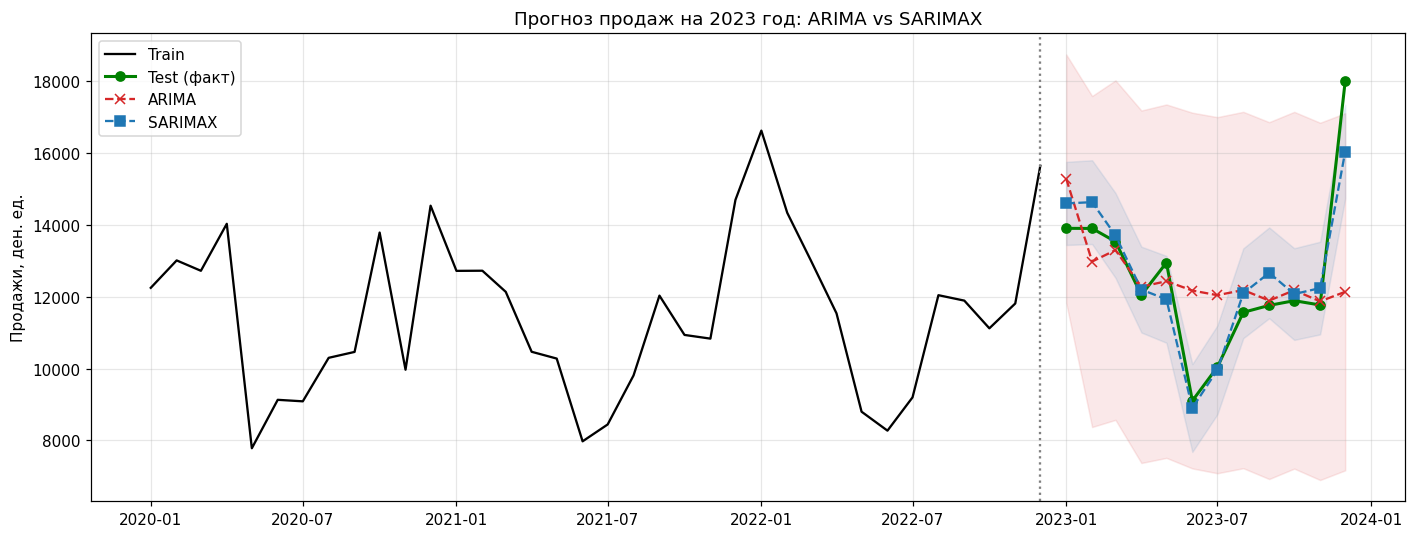

,Факт,ARIMA,SARIMAX
Date,,,
2023-01-01,13904,"15,287.000","14,597.000"
2023-02-01,13901,"12,980.000","14,632.000"
2023-03-01,13534,"13,297.000","13,705.000"
2023-04-01,12048,"12,278.000","12,199.000"
2023-05-01,12949,"12,433.000","11,927.000"
2023-06-01,9104,"12,172.000","8,903.000"
2023-07-01,10042,"12,043.000","9,965.000"
2023-08-01,11566,"12,187.000","12,096.000"
2023-09-01,11759,"11,893.000","12,665.000"


SARIMAX без экзогенных признаков: test MSE = 1,967,010, MAPE = 7.01%
SARIMAX с экзогенными признаками: test MSE = 612,158, MAPE = 4.36%


In [20]:
# Прогноз на тестовый горизонт (12 мес.) с доверительными интервалами
fc_arima = best_arima.get_forecast(steps=len(test))
mean_arima = fc_arima.predicted_mean
ci_arima = fc_arima.conf_int()

fc_sarimax = best_sarimax.get_forecast(steps=len(test), exog=exog_test)
mean_sarimax = fc_sarimax.predicted_mean
ci_sarimax = fc_sarimax.conf_int()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train, label="Train", color="black")
ax.plot(test.index, test, label="Test (факт)", color="green", marker="o", lw=2)
ax.plot(test.index, mean_arima, label="ARIMA", color="tab:red", ls="--", marker="x")
ax.fill_between(test.index, ci_arima.iloc[:, 0], ci_arima.iloc[:, 1], color="tab:red", alpha=0.10)
ax.plot(test.index, mean_sarimax, label="SARIMAX", color="tab:blue", ls="--", marker="s")
ax.fill_between(test.index, ci_sarimax.iloc[:, 0], ci_sarimax.iloc[:, 1],
                color="tab:blue", alpha=0.10)
ax.axvline(train.index[-1], color="gray", ls=":")
ax.set_title("Прогноз продаж на 2023 год: ARIMA vs SARIMAX")
ax.set_ylabel("Продажи, ден. ед.")
ax.legend()
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    "Факт": test,
    "ARIMA": np.asarray(mean_arima),
    "SARIMAX": np.asarray(mean_sarimax),
})
display(forecast_df.round(0))

# Та же SARIMAX без экзогенных признаков: вклад exog out-of-sample
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima_noexog = fit_sarimax(train, best_sarimax_order, best_sarimax_seasonal)
    pred_noex = np.asarray(sarima_noexog.get_forecast(steps=len(test)).predicted_mean)
for lbl, pred in [("без экзогенных признаков", pred_noex),
                  ("с экзогенными признаками", np.asarray(mean_sarimax))]:
    e = test.values - pred
    print(f"SARIMAX {lbl}: test MSE = {np.mean(e ** 2):,.0f}, "
          f"MAPE = {np.mean(np.abs(e / test.values)) * 100:.2f}%")

#### 2.2.1. Прогноз на 2024 год (переобучение на всех данных)

Оценка на 2023 уже проведена; теперь переобучаем модели на всех 48 наблюдениях и прогнозируем
12 мес. 2024 - максимальный полный сезонный цикл, оправданный 4-летней историей.
Экзогенные признаки на будущее заданы допущением: `Promotion = 0`, декабрь - `HolidayMonth = 1`.

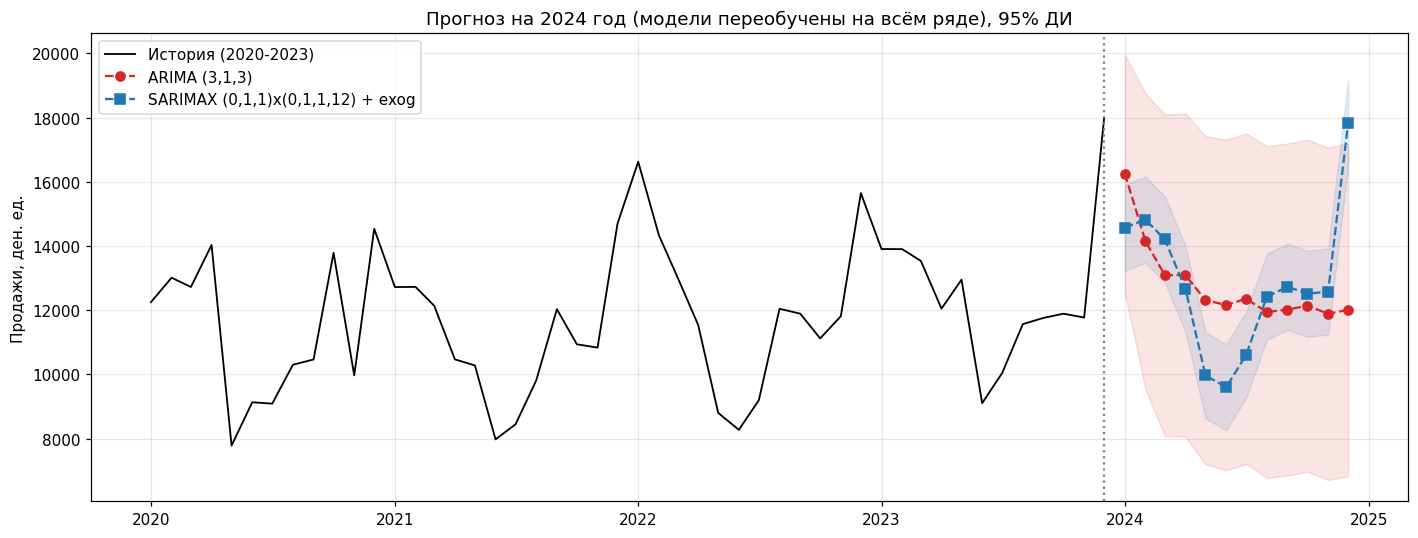

Ширина 95% ДИ SARIMAX: h=1 - 2680, h=12 - 2682, h=24 - 3188 ден. ед.
Декабрь-2024: SARIMAX 17833 vs ARIMA 12011 - несезонная ARIMA не ловит пик.


In [21]:
fut_idx = pd.date_range("2024-01-01", periods=12, freq="MS")
exog_full = exog.astype(float)
exog_fut = pd.DataFrame({"Promotion": 0.0,
                         "HolidayMonth": [0.0] * 11 + [1.0]}, index=fut_idx)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arima_full = fit_sarimax(ts, best_arima_order)
    sarimax_full = fit_sarimax(ts, best_sarimax_order, best_sarimax_seasonal, exog_full)

fc_a = arima_full.get_forecast(steps=12)
fc_s = sarimax_full.get_forecast(steps=12, exog=exog_fut)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, color="black", lw=1.2, label="История (2020-2023)")
ax.plot(fut_idx, np.asarray(fc_a.predicted_mean), "o--", color="tab:red",
        label="ARIMA (3,1,3)")
ax.fill_between(fut_idx, *np.asarray(fc_a.conf_int()).T, color="tab:red", alpha=0.12)
ax.plot(fut_idx, np.asarray(fc_s.predicted_mean), "s--", color="tab:blue",
        label="SARIMAX (0,1,1)x(0,1,1,12) + exog")
ax.fill_between(fut_idx, *np.asarray(fc_s.conf_int()).T, color="tab:blue", alpha=0.12)
ax.axvline(ts.index[-1], color="gray", ls=":")
ax.set_title("Прогноз на 2024 год (модели переобучены на всём ряде), 95% ДИ")
ax.set_ylabel("Продажи, ден. ед.")
ax.legend()
plt.tight_layout()
plt.show()

# Ширина 95% ДИ на h = 1/12/24 - обоснование горизонта
exog_fut24 = pd.concat([exog_fut,
                        exog_fut.set_index(pd.date_range("2025-01-01", periods=12, freq="MS"))])
ci24 = np.asarray(sarimax_full.get_forecast(steps=24, exog=exog_fut24).conf_int())
w = ci24[:, 1] - ci24[:, 0]
print("Ширина 95%% ДИ SARIMAX: h=1 - %.0f, h=12 - %.0f, h=24 - %.0f ден. ед." % (w[0], w[11], w[23]))
print("Декабрь-2024: SARIMAX %.0f vs ARIMA %.0f - несезонная ARIMA не ловит пик."
      % (np.asarray(fc_s.predicted_mean)[-1], np.asarray(fc_a.predicted_mean)[-1]))

**Выводы по 2.2.**
* Лучшие по AIC: ARIMA(3,1,3) и SARIMAX(0,1,1)x(0,1,1,12) + exog; разности d=1, D=1 - как и ожидалось из EDA.
* ARIMA(3,1,3) переобучена (корень MA ~ 0.99 - граница обратимости); по BIC предпочтительнее (0,1,3), качество на тесте близкое.
* Экзогенные признаки работают: без них test MSE 1.97 млн против 0.61 млн с ними (хотя отдельные коэффициенты незначимы).
* Горизонт 12 мес. - полный сезонный цикл; 95% ДИ ~ 2.7 тыс. ден. ед. при h <= 12 и ~ 3.2 тыс. при h = 24.

---
## 2.3. Оценка качества моделей

### 2.3.1. Метрики точности прогноза (MSE, R² и др.)


In [22]:
def forecast_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mse = np.mean(err ** 2)
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": np.mean(np.abs(err)),
        "R2": 1 - ss_res / ss_tot,
        "MAPE, %": np.mean(np.abs(err / y_true)) * 100,
    }

eval_df = pd.DataFrame({
    "ARIMA": forecast_metrics(test, mean_arima),
    "SARIMAX": forecast_metrics(test, mean_sarimax),
}).T
eval_df


,MSE,RMSE,MAE,R2,"MAPE, %"
ARIMA,"4,280,840.400","2,069.019","1,279.923",0.074,10.016
SARIMAX,"612,157.931",782.405,591.170,0.868,4.361


### 2.3.2. Информационные критерии (AIC, BIC)

Модели оценены на одной выборке (n = 36), но невложены (разные разности и регрессоры), поэтому
межсемейное сравнение AIC/BIC ориентировочное; решающий критерий - тест (п. 2.3.1). Внутри сеток
критерии полностью корректны. k указано включая sigma2: 7 у ARIMA, 5 у SARIMAX.

In [23]:
ic_df = pd.DataFrame([
    {"Модель": "ARIMA", "Порядок": str(best_arima_order),
     "AIC": best_arima.aic, "BIC": best_arima.bic,
     "LogLik": best_arima.llf,
     "k (число параметров)": len(best_arima.params),
     "n (наблюдений)": int(best_arima.nobs)},
    {"Модель": "SARIMAX", "Порядок": f"{best_sarimax_order} x {best_sarimax_seasonal}",
     "AIC": best_sarimax.aic, "BIC": best_sarimax.bic,
     "LogLik": best_sarimax.llf,
     "k (число параметров)": len(best_sarimax.params),
     "n (наблюдений)": int(best_sarimax.nobs)},
]).set_index("Модель")
ic_df

,Порядок,AIC,BIC,LogLik,k (число параметров),n (наблюдений)
Модель,,,,,,
ARIMA,"(3, 1, 3)",561.265,571.303,-273.633,7,36
SARIMAX,"(0, 1, 1) x (0, 1, 1, 12)",150.695,151.681,-70.347,5,36


### 2.3.3. Анализ остатков: нормальность, автокоррелированность, гомоскедастичность


In [24]:
def residual_diagnostics(res, name):
    resid = res.resid.dropna()
    jb_p = jarque_bera(resid)[1]
    # Ljung-Box для остатков подобранной модели: вычитаем оценённые параметры из df (model_df)
    n_est = len(res.params) - 1
    lb = acorr_ljungbox(resid, lags=[12], model_df=n_est, return_df=True)
    lb_p = lb["lb_pvalue"].iloc[0]
    fit_vals = np.asarray(res.fittedvalues)[-len(resid):]
    bp_p = het_breuschpagan(resid.values, sm.add_constant(fit_vals))[1]
    out = {
        "Модель": name,
        "Jarque-Bera p": jb_p,
        "Ljung-Box(12) p": lb_p,
        "поправка df (model_df)": n_est,
        "Breusch-Pagan p": bp_p,
        "Нормальность": "OK" if jb_p > 0.05 else "нарушена",
        "Автокорреляция": "нет" if lb_p > 0.05 else "ЕСТЬ",
        "Гомоскедастичность": "OK" if bp_p > 0.05 else "нарушена",
    }
    return out

resid_check = pd.DataFrame([
    residual_diagnostics(best_arima, "ARIMA"),
    residual_diagnostics(best_sarimax, "SARIMAX"),
]).set_index("Модель")
resid_check

,Jarque-Bera p,Ljung-Box(12) p,поправка df (model_df),Breusch-Pagan p,Нормальность,Автокорреляция,Гомоскедастичность
Модель,,,,,,,
ARIMA,0.000,0.163,6,0.000,нарушена,нет,нарушена
SARIMAX,0.000,0.061,4,0.192,нарушена,нет,OK


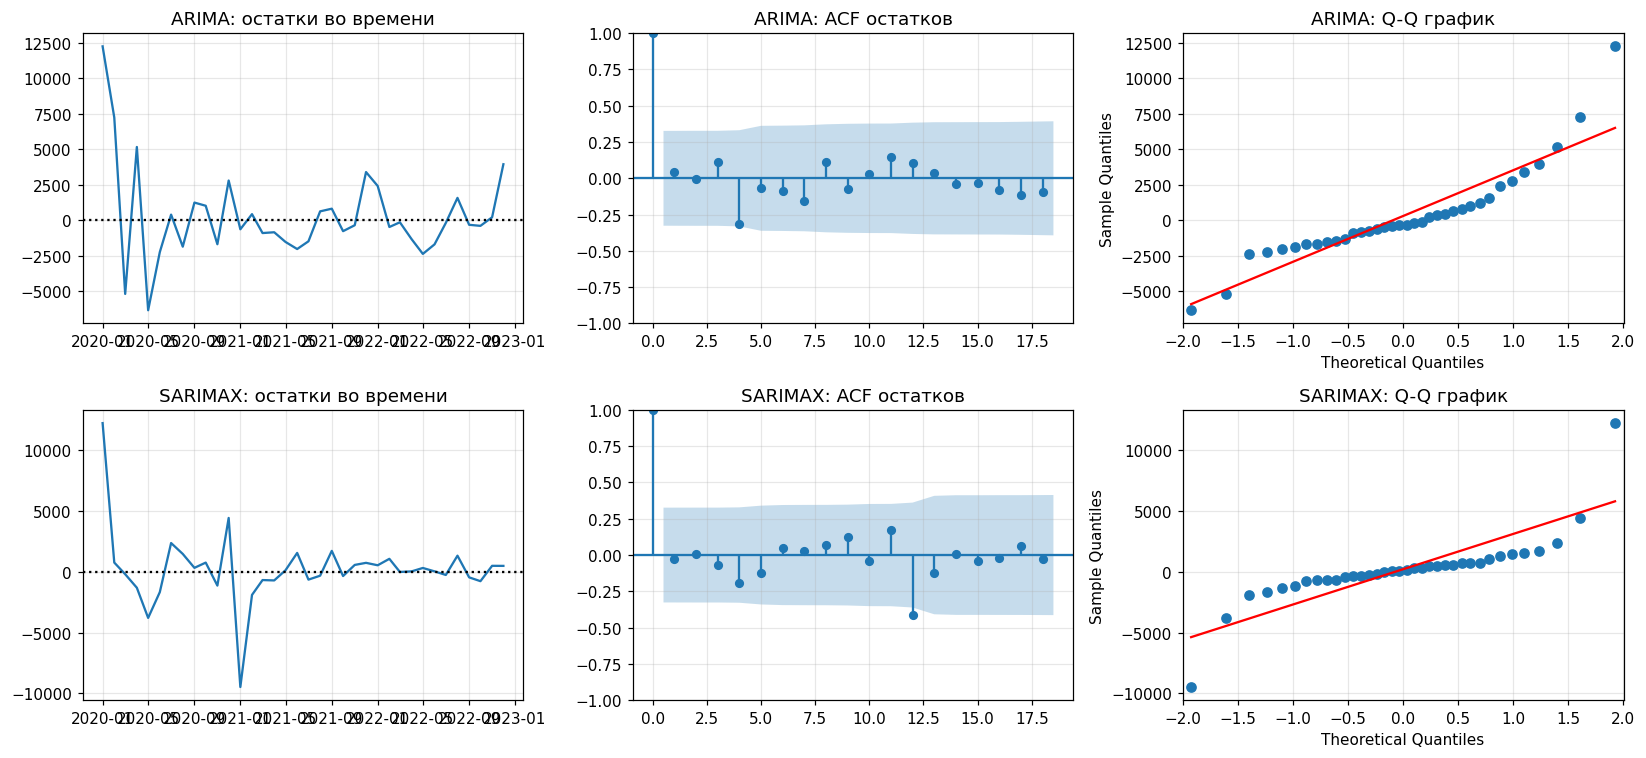

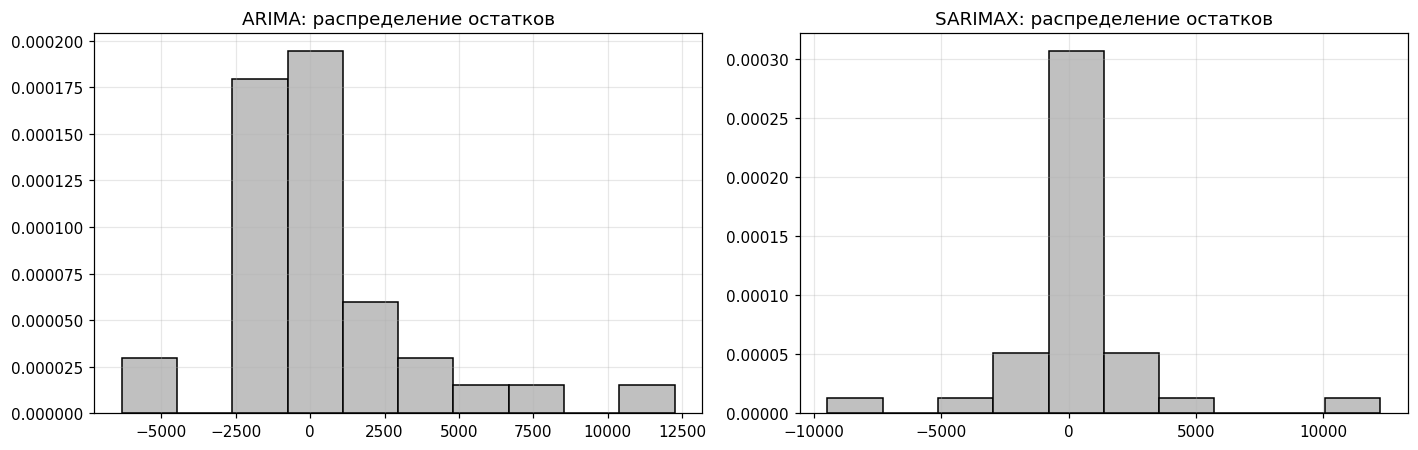

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (res, name) in enumerate([(best_arima, "ARIMA"), (best_sarimax, "SARIMAX")]):
    r = res.resid.dropna()
    axes[i, 0].plot(r.index, r.values, color="tab:blue")
    axes[i, 0].axhline(0, color="k", ls=":")
    axes[i, 0].set_title(f"{name}: остатки во времени")
    plot_acf(r, lags=18, ax=axes[i, 1])
    axes[i, 1].set_title(f"{name}: ACF остатков")
    sm.qqplot(r, line="s", ax=axes[i, 2])
    axes[i, 2].set_title(f"{name}: Q-Q график")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (res, name) in zip(axes, [(best_arima, "ARIMA"), (best_sarimax, "SARIMAX")]):
    ax.hist(res.resid.dropna(), bins=10, density=True, color="silver", edgecolor="k")
    ax.set_title(f"{name}: распределение остатков")
plt.tight_layout()
plt.show()


**Выводы по 2.3.**
* Тест: SARIMAX заметно точнее - MSE 0.61 млн против 4.28 млн, MAPE 4.4% против 10.0%, R2 0.87 против 0.07.
* AIC/BIC у SARIMAX тоже ниже при меньшем числе параметров (5 против 7).
* Остатки: автокорреляции нет (Ljung-Box p 0.16 / 0.06); нормальность отвергнута у обеих (JB, короткая выборка); гетероскедастичность только у ARIMA (BP).
* Предпочтительна SARIMAX - см. п. 2.4.

---
## 2.4. Документирование и интерпретация

### Сводные выводы по этапам


In [26]:
# Итоговая сравнительная таблица: точность + информационные критерии
final_report = (eval_df[["MSE", "RMSE", "MAE", "R2", "MAPE, %"]]
                .join(ic_df[["AIC", "BIC"]]))
final_report.round(2)


,MSE,RMSE,MAE,R2,"MAPE, %",AIC,BIC
ARIMA,"4,280,840.400","2,069.020","1,279.920",0.070,10.020,561.270,571.300
SARIMAX,"612,157.930",782.410,591.170,0.870,4.360,150.690,151.680


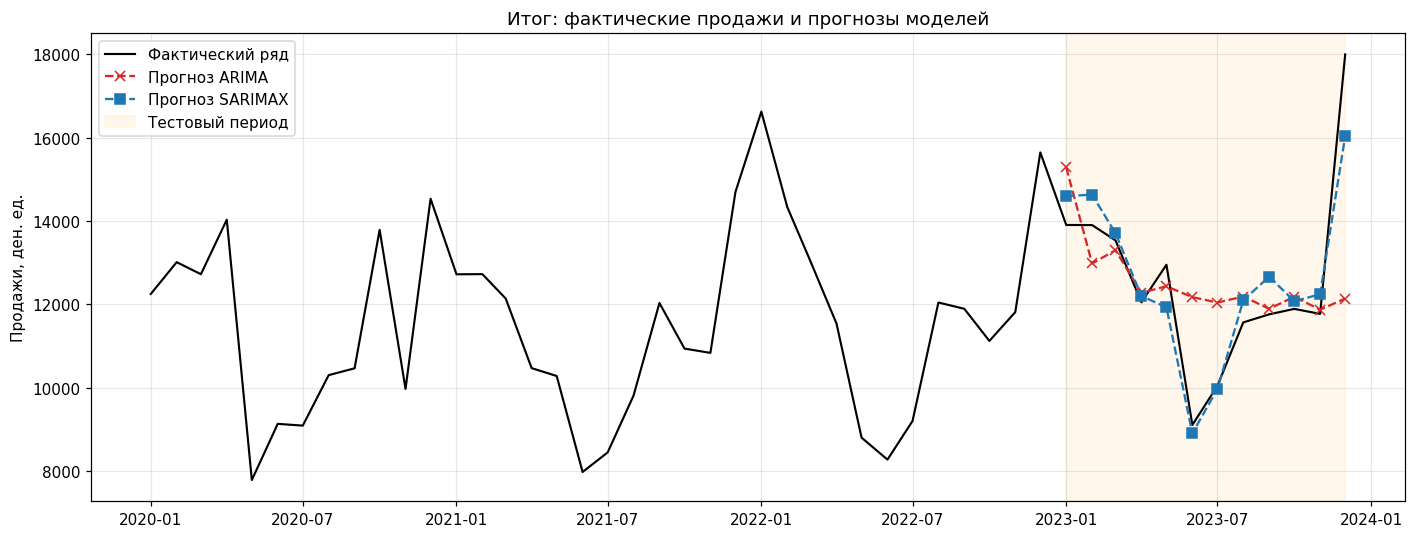

In [27]:
# Итоговый график: факт и прогнозы обеих моделей
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, color="black", lw=1.4, label="Фактический ряд")
ax.plot(test.index, np.asarray(mean_arima), color="tab:red", ls="--",
        marker="x", label="Прогноз ARIMA")
ax.plot(test.index, np.asarray(mean_sarimax), color="tab:blue", ls="--",
        marker="s", label="Прогноз SARIMAX")
ax.axvspan(test.index[0], test.index[-1], color="orange", alpha=0.08, label="Тестовый период")
ax.set_title("Итог: фактические продажи и прогнозы моделей")
ax.set_ylabel("Продажи, ден. ед.")
ax.legend()
plt.tight_layout()
plt.show()


### 2.4.1. Итоговые выводы

**EDA.** 48 регулярных наблюдений, слабый тренд, сильная годовая сезонность (пик в декабре,
провал в мае-июне). Тесты стационарность не отвергают, но страховочно используем разности
d = 1, D = 1. Декомпозиции согласованы (сила сезонности 0.83-0.85), FFT даёт период 12 мес.,
вейвлеты - устойчивость цикла во времени.

**Модели.** По AIC выбраны ARIMA(3,1,3) и SARIMAX(0,1,1)x(0,1,1,12) + exog; первая переобучена
(по BIC лучше (0,1,3)). Прогноз - 12 мес.: оценка на отложенном 2023 и прогноз 2024 на моделях,
переобученных на всех данных.

**Качество.** SARIMAX: MSE 0.61 млн, MAPE 4.4%, R2 0.87; ARIMA: 4.28 млн, 10.0%, 0.07.
Остатки без автокорреляции у обеих моделей, нормальность отвергнута, гетероскедастичность только у ARIMA.

### 2.4.2. Предпочтительная модель
**SARIMAX(0,1,1)x(0,1,1,12) + exog**: на порядок точнее на тесте, воспроизводит декабрьский пик
(прогноз-2024: ~17.8 тыс. против ~12.0 тыс. у ARIMA), остатки чище, параметров меньше.
Простые альтернативы: SARIMA без exog (MSE 1.97 млн) и ARIMA(0,1,3) по BIC.

### 2.4.3. Ограничения и рекомендации
* 48 наблюдений (~24 эффективных после сезонной разности) - сезонные параметры нестабильны.
* HolidayMonth не идентифицирован (колинеарен D=1); вклад exog подтверждён out-of-sample, а не t-статистиками.
* Остатки не нормальны - аналитические ДИ могут быть занижены.
* Перспективно: расширенные регрессоры, Prophet/ETS/бустинг на лагах, скользящая кросс-валидация; модель обновлять по мере новых данных.